# Exploratory Data Analysis (EDA) - Welding Quality Dataset

---

## Introduction

This notebook provides a **comprehensive exploratory data analysis** of the welding quality dataset. The goal is to:

1. **Understand the data structure** and characteristics
2. **Identify patterns and relationships** between features
3. **Explore target variables** (mechanical properties)
4. **Discover insights** for feature engineering and modeling
5. **Validate assumptions** about the data

### Dataset Overview

The dataset contains welding data with:
- **Chemical composition** (weight% and ppm)
- **Welding process parameters** (current, voltage, heat input, etc.)
- **Post-weld treatments** (heat treatment temperature and time)
- **Mechanical properties** (yield strength, tensile strength, elongation, etc.)
- **Microstructure** (ferrite, martensite percentages)



## 1. Data Loading and Setup

### Import Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency, pearsonr, spearmanr, normaltest, shapiro
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)
%matplotlib inline

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 4)


✓ All libraries imported successfully!


### Load the Data

In [ ]:
# Load the cleaned dataset
# Note: If preprocessing was run, this will load welddb_cleaned.csv
# Otherwise, we'll load from welddb.data and apply basic cleaning

import os

if os.path.exists('welddb_cleaned.csv'):
    print("Loading preprocessed data...")
    df = pd.read_csv('welddb_cleaned.csv')
    print(f"✓ Loaded preprocessed data: {df.shape}")
else:
    print("Preprocessed data not found. Loading raw data...")
    df = pd.read_csv('welddb.data', header=None, delim_whitespace=True)

    # Assign column names
    column_names = [
        "Carbon concentration (weight%)",
        "Silicon concentration (weight%)",
        "Manganese concentration (weight%)",
        "Sulphur concentration (weight%)",
        "Phosphorus concentration (weight%)",
        "Nickel concentration (weight%)",
        "Chromium concentration (weight%)",
        "Molybdenum concentration (weight%)",
        "Vanadium concentration (weight%)",
        "Copper concentration (weight%)",
        "Cobalt concentration (weight%)",
        "Tungsten concentration (weight%)",
        "Oxygen concentration (ppm by weight)",
        "Titanium concentration (ppm by weight)",
        "Nitrogen concentration (ppm by weight)",
        "Aluminium concentration (ppm by weight)",
        "Boron concentration (ppm by weight)",
        "Niobium concentration (ppm by weight)",
        "Tin concentration (ppm by weight)",
        "Arsenic concentration (ppm by weight)",
        "Antimony concentration (ppm by weight)",
        "Current (A)",
        "Voltage (V)",
        "AC or DC",
        "Electrode polarity (positive or negative)",
        "Heat input (kJmm-1)",
        "Interpass temperature (°C)",
        "Type of weld",
        "Post weld heat treatment temperature (°C)",
        "Post weld heat treatment time (hours)",
        "Yield strength (MPa)",
        "Ultimate tensile strength (MPa)",
        "Elongation (%)",
        "Reduction of Area (%)",
        "Charpy temperature (°C)",
        "Charpy impact toughness (J)",
        "Hardness (kgmm-2)",
        "50% FATT",
        "Primary ferrite in microstructure (%)",
        "Ferrite with second phase (%)",
        "Acicular ferrite (%)",
        "Martensite (%)",
        "Ferrite with carbide aggregate (%)",
        "Weld ID"
    ]
    df.columns = column_names

    # Basic cleaning
    df.replace("N", np.nan, inplace=True)

    print(f"✓ Loaded raw data: {df.shape}")

# Display basic info
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head()

Loading preprocessed data...
✓ Loaded preprocessed data: (1652, 38)

Dataset Shape: 1652 rows × 38 columns
Memory Usage: 0.65 MB


,Carbon concentration (weight%),Silicon concentration (weight%),Manganese concentration (weight%),Sulphur concentration (weight%),Phosphorus concentration (weight%),Nickel concentration (weight%),Chromium concentration (weight%),Molybdenum concentration (weight%),Vanadium concentration (weight%),Copper concentration (weight%),Oxygen concentration (ppm by weight),Titanium concentration (ppm by weight),Nitrogen concentration (ppm by weight),Aluminium concentration (ppm by weight),Boron concentration (ppm by weight),Niobium concentration (ppm by weight),Current (A),Voltage (V),AC or DC,Electrode polarity (positive or negative),Heat input (kJmm-1),Interpass temperature (°C),Type of weld,Post weld heat treatment temperature (°C),Post weld heat treatment time (hours),Yield strength (MPa),Ultimate tensile strength (MPa),Elongation (%),Reduction of Area (%),Charpy temperature (°C),Charpy impact toughness (J),Weld ID,Oxygen concentration (weight%),Titanium concentration (weight%),Nitrogen concentration (weight%),Aluminium concentration (weight%),Boron concentration (weight%),Niobium concentration (weight%)
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,21.0,1.0,1.0,1.0,200.0,MMA,250.0,14.0,392.0,466.0,31.9,80.6,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw,NaN,NaN,NaN,NaN,NaN,NaN
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,21.0,1.0,1.0,1.0,200.0,MMA,0.0,0.0,NaN,NaN,NaN,NaN,-28.0,100.0,Evans-Ni/CMn-1990/1991-0Aawch,NaN,NaN,NaN,NaN,NaN,NaN
2,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,21.0,1.0,1.0,1.0,200.0,MMA,580.0,2.0,370.0,456.0,35.2,80.6,-38.0,100.0,Evans-Ni/CMn-1990/1991-0Aht,NaN,NaN,NaN,NaN,NaN,NaN
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,21.0,1.0,1.0,1.0,200.0,MMA,250.0,14.0,413.0,498.0,31.2,80.6,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw,NaN,NaN,NaN,NaN,NaN,NaN
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,21.0,1.0,1.0,1.0,200.0,MMA,0.0,0.0,NaN,NaN,NaN,NaN,-48.0,100.0,Evans-Ni/CMn-1990/1991-0Bawch,NaN,NaN,NaN,NaN,NaN,NaN


### Initial Data Overview

In [ ]:
# Display comprehensive dataset information
print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"\n📊 Dimensions:")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

print(f"\n🔢 Data Types:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

print(f"\n❓ Missing Values:")
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
missing_pct = (missing_cells / total_cells) * 100
print(f"   Total: {missing_cells:,} ({missing_pct:.2f}%)")
print(f"   Columns with missing: {(df.isnull().sum() > 0).sum()}")

print(f"\n🔄 Duplicates:")
duplicates = df.duplicated().sum()
print(f"   Duplicate rows: {duplicates}")

print(f"\n💾 Memory:")
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"   Total memory: {memory_mb:.2f} MB")

print("\n" + "="*80)

DATASET OVERVIEW

📊 Dimensions:
   Rows: 1,652
   Columns: 38

🔢 Data Types:
   float64: 36 columns
   object: 2 columns

❓ Missing Values:
   Total: 19,292 (30.73%)
   Columns with missing: 31

🔄 Duplicates:
   Duplicate rows: 0

💾 Memory:
   Total memory: 0.65 MB



In [ ]:
# Display detailed info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 38 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Carbon concentration (weight%)             1652 non-null   float64
 1   Silicon concentration (weight%)            1652 non-null   float64
 2   Manganese concentration (weight%)          1652 non-null   float64
 3   Sulphur concentration (weight%)            1648 non-null   float64
 4   Phosphorus concentration (weight%)         1642 non-null   float64
 5   Nickel concentration (weight%)             697 non-null    float64
 6   Chromium concentration (weight%)           784 non-null    float64
 7   Molybdenum concentration (weight%)         793 non-null    float64
 8   Vanadium concentration (weight%)           928 non-null    float64
 9   Copper concentration (weight%)             578 non-null    float64
 10  Oxygen concentration (pp

### Define Feature Groups

For systematic analysis, we'll organize features into logical groups.

In [ ]:
# Define feature groups
feature_groups = {
    'Chemical Composition (weight%)': [
        "Carbon concentration (weight%)",
        "Silicon concentration (weight%)",
        "Manganese concentration (weight%)",
        "Sulphur concentration (weight%)",
        "Phosphorus concentration (weight%)",
        "Nickel concentration (weight%)",
        "Chromium concentration (weight%)",
        "Molybdenum concentration (weight%)",
        "Vanadium concentration (weight%)",
        "Copper concentration (weight%)",
        "Cobalt concentration (weight%)",
        "Tungsten concentration (weight%)"
    ],
    'Chemical Composition (ppm)': [
        "Oxygen concentration (ppm by weight)",
        "Titanium concentration (ppm by weight)",
        "Nitrogen concentration (ppm by weight)",
        "Aluminium concentration (ppm by weight)",
        "Boron concentration (ppm by weight)",
        "Niobium concentration (ppm by weight)",
        "Tin concentration (ppm by weight)",
        "Arsenic concentration (ppm by weight)",
        "Antimony concentration (ppm by weight)"
    ],
    'Welding Process Parameters': [
        "Current (A)",
        "Voltage (V)",
        "AC or DC",
        "Electrode polarity (positive or negative)",
        "Heat input (kJmm-1)",
        "Interpass temperature (°C)",
        "Type of weld"
    ],
    'Post-Weld Treatment': [
        "Post weld heat treatment temperature (°C)",
        "Post weld heat treatment time (hours)"
    ],
    'Mechanical Properties (Targets)': [
        "Yield strength (MPa)",
        "Ultimate tensile strength (MPa)",
        "Elongation (%)",
        "Reduction of Area (%)",
        "Charpy impact toughness (J)"
    ],
    'Microstructure': [
        "Primary ferrite in microstructure (%)",
        "Ferrite with second phase (%)",
        "Acicular ferrite (%)",
        "Martensite (%)",
        "Ferrite with carbide aggregate (%)"
    ]
}


Feature Groups Summary:

Chemical Composition (weight%): 10 features
  • Carbon concentration (weight%)
  • Silicon concentration (weight%)
  • Manganese concentration (weight%)
  • Sulphur concentration (weight%)
  • Phosphorus concentration (weight%)
  ... and 5 more

Chemical Composition (ppm): 6 features
  • Oxygen concentration (ppm by weight)
  • Titanium concentration (ppm by weight)
  • Nitrogen concentration (ppm by weight)
  • Aluminium concentration (ppm by weight)
  • Boron concentration (ppm by weight)
  ... and 1 more

Welding Process Parameters: 7 features
  • Current (A)
  • Voltage (V)
  • AC or DC
  • Electrode polarity (positive or negative)
  • Heat input (kJmm-1)
  ... and 2 more

Post-Weld Treatment: 2 features
  • Post weld heat treatment temperature (°C)
  • Post weld heat treatment time (hours)

Mechanical Properties (Targets): 6 features
  • Yield strength (MPa)
  • Ultimate tensile strength (MPa)
  • Elongation (%)
  • Reduction of Area (%)
  • Charpy tempera

These logical groups were created according to the classification of each feature. For example, the chemical composition was divided into two distinct classes: concentrations expressed as weight percentage (weight%) and those expressed in parts per million (ppm). We therefore grouped the variables following this logic.

Additionally, the class that encompasses all our target variables is Mechanical Properties, as these directly assess the quality of a weld. These properties include tensile strength, yield strength, elongation, and other essential mechanical performance indicators that determine the structural integrity and reliability of welded joints.


## 2. Missing Data Analysis

### Overview of Missing Values

Understanding missing data patterns is crucial for:
- Identifying data quality issues
- Choosing appropriate imputation strategies
- Understanding potential biases in the dataset

In [ ]:
# Calculate comprehensive missing data statistics
missing_data = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100),
    'Present_Count': df.notnull().sum().values,
    'Data_Type': df.dtypes.values
})

missing_data = missing_data.sort_values('Missing_Percentage', ascending=False)
missing_data = missing_data.reset_index(drop=True)

# Display features with missing values
features_with_missing = missing_data[missing_data['Missing_Count'] > 0]

print(f"Features with Missing Values: {len(features_with_missing)} out of {len(df.columns)}")
print("\nTop 20 Features with Highest Missing Percentages:")
print("="*80)
print(features_with_missing.head(20).to_string(index=False))

# Summary statistics
print(f"\n\nMissing Data Summary:")
print("="*80)
print(f"Total missing cells: {missing_data['Missing_Count'].sum():,}")
print(f"Overall missing percentage: {missing_data['Missing_Percentage'].mean():.2f}%")
print(f"\nMissing value distribution:")
print(f"  < 10% missing: {(missing_data['Missing_Percentage'] < 10).sum()} features")
print(f"  10-30% missing: {((missing_data['Missing_Percentage'] >= 10) & (missing_data['Missing_Percentage'] < 30)).sum()} features")
print(f"  30-50% missing: {((missing_data['Missing_Percentage'] >= 30) & (missing_data['Missing_Percentage'] < 50)).sum()} features")
print(f"  50-70% missing: {((missing_data['Missing_Percentage'] >= 50) & (missing_data['Missing_Percentage'] < 70)).sum()} features")
print(f"  > 70% missing: {(missing_data['Missing_Percentage'] >= 70).sum()} features")

Features with Missing Values: 31 out of 38

Top 20 Features with Highest Missing Percentages:
                                Feature  Missing_Count  Missing_Percentage  Present_Count Data_Type
          Boron concentration (weight%)           1148             69.4915            504   float64
    Boron concentration (ppm by weight)           1148             69.4915            504   float64
         Copper concentration (weight%)           1074             65.0121            578   float64
         Nickel concentration (weight%)            955             57.8087            697   float64
                         Elongation (%)            952             57.6271            700   float64
                  Reduction of Area (%)            947             57.3245            705   float64
        Ultimate tensile strength (MPa)            914             55.3269            738   float64
  Niobium concentration (ppm by weight)            900             54.4794            752   float64
      

The dataset contains a substantial amount of missing data. This represents a significant challenge for model development and requires careful handling strategies.

As shown in the table above, all target variables (mechanical properties) appear in the top 20 features with the highest missing percentages.

This high missingness in target variables is particularly concerning as it directly impacts our ability to train predictive models and may introduce bias in the results.

We attempted to classify these missing values into three categories: MCAR, MAR, and MNAR.

MCAR: This category includes missing values that occur completely by chance, without any relationship to other variables—in other words, "bad luck." The probability of missingness is the same for all observations.

MAR: This category encompasses missing values whose probability of being missing depends on observed values in the dataset, but not on the missing values themselves. For instance, the simultaneous missingness of **Boron concentration in weight% and ppm** likely falls into this category. Since these two measurements represent the same chemical element expressed in different units, laboratories typically perform only one measurement and convert it if needed. The missingness in one format depends on whether the measurement was taken at all, not on the actual boron concentration value. An other example can be that certain properties are measured only for specific weld types or experimental conditions.

MNAR: These are the most challenging missing values to handle because the probability of missingness depends on the unobserved values themselves or on other missing variables. A clear example in our dataset is the relationship between **Charpy impact toughness and Charpy temperature**. If the Charpy impact test was not performed, then naturally the test temperature cannot be recorded either. The missingness of one variable directly causes the missingness of the other, and both are related to the decision not to conduct the test (possibly due to cost, time constraints, or specific experimental protocols).

Understanding the mechanism behind missing data is crucial for selecting appropriate imputation strategies. MCAR data can often be safely deleted or imputed with simple methods, MAR data requires more sophisticated imputation techniques that leverage observed relationships, while MNAR data may require domain knowledge or specialized modeling approaches to avoid introducing bias into our analysis.


### Visualize Missing Data Patterns

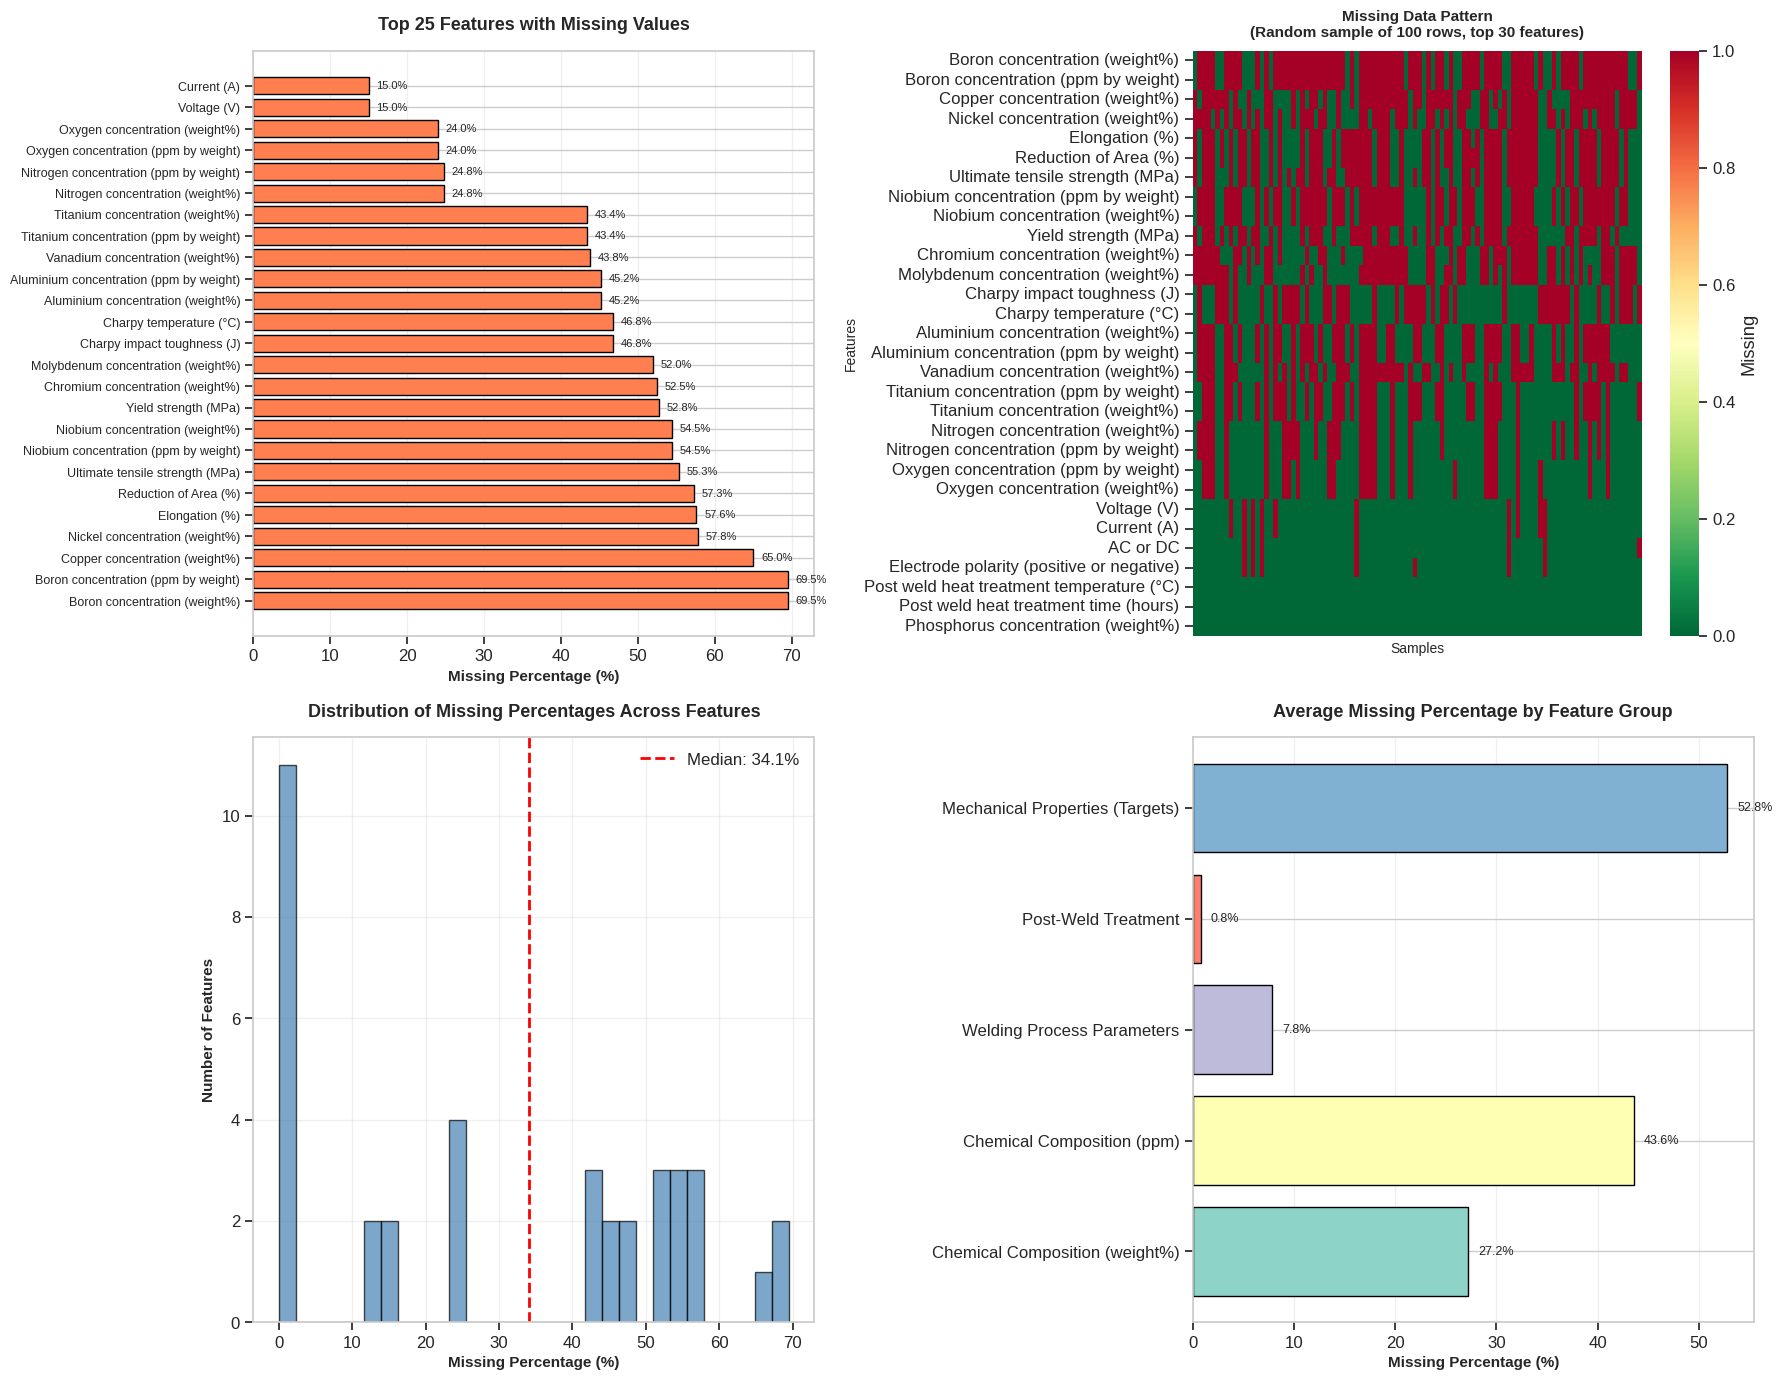


✓ Missing data visualizations complete!


In [ ]:
# Create comprehensive missing data visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Bar plot of missing percentages (top 25)
ax = axes[0, 0]
top_missing = features_with_missing.head(25)
bars = ax.barh(range(len(top_missing)), top_missing['Missing_Percentage'], color='coral', edgecolor='black')
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing['Feature'], fontsize=9)
ax.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('Top 25 Features with Missing Values', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, (idx, row) in enumerate(top_missing.iterrows()):
    ax.text(row['Missing_Percentage'] + 1, i, f"{row['Missing_Percentage']:.1f}%",
            va='center', fontsize=8)

# 2. Missing data heatmap (sample)
ax = axes[0, 1]
sample_size = min(100, len(df))
sample_cols = features_with_missing.head(30)['Feature'].tolist()
sample_df = df[sample_cols].sample(n=sample_size, random_state=42)
missing_matrix = sample_df.isnull().T

sns.heatmap(missing_matrix, cmap='RdYlGn_r', cbar=True, ax=ax,
            yticklabels=True, xticklabels=False, cbar_kws={'label': 'Missing'})
ax.set_title(f'Missing Data Pattern\n(Random sample of {sample_size} rows, top 30 features)',
            fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Features', fontsize=10)
ax.set_xlabel('Samples', fontsize=10)

# 3. Distribution of missing percentages
ax = axes[1, 0]
ax.hist(missing_data['Missing_Percentage'], bins=30, color='steelblue',
       edgecolor='black', alpha=0.7)
ax.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Features', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Missing Percentages Across Features',
            fontsize=13, fontweight='bold', pad=15)
ax.grid(alpha=0.3)
ax.axvline(missing_data['Missing_Percentage'].median(), color='red', linestyle='--',
          linewidth=2, label=f'Median: {missing_data["Missing_Percentage"].median():.1f}%')
ax.legend()

# 4. Missing by feature group
ax = axes[1, 1]
group_missing = {}
for group_name, cols in feature_groups.items():
    group_df = df[cols]
    group_missing[group_name] = (group_df.isnull().sum().sum() / (len(group_df) * len(cols)) * 100)

groups = list(group_missing.keys())
values = list(group_missing.values())
colors = plt.cm.Set3(range(len(groups)))

bars = ax.barh(groups, values, color=colors, edgecolor='black')
ax.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('Average Missing Percentage by Feature Group', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, (group, value) in enumerate(zip(groups, values)):
    ax.text(value + 1, i, f'{value:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Distribution of missing percentages accross features:
The histogram shows a bimodal distribution of missing percentages across all features, with a median of 34.1%. We observe two main clusters:
- A large concentration of features with very low missingness (0-10%)
- A second cluster around 40-70% missing, indicating features that were only occasionally recorded

This bimodal pattern suggests two distinct data collection protocols: core measurements that were performed consistently across all samples, and supplementary measurements (likely trace elements and specific mechanical tests) that were conducted only in certain experimental conditions or studies.

Average missing percentage by feature group:

For the Mechanical Properties (Targets), we have the highest average missingness among all groups. This is particularly concerning as these are our prediction targets. This suggests that not all welding samples underwent complete mechanical testing.

For Chemical Composition ppm and weight, we have also a large percentage of missing values. Maybe it's because these measurements require specialized analytical equipment.

This analysis confirms that missing data is not random but rather follows systematic patterns.

The high missingness in target variables will require careful consideration in modeling strategies, potentially including semi-supervised learning approaches or separate models for different target subsets.

## 3. Univariate Analysis

Examining each feature individually to understand their distributions, central tendencies, and spread.

### 3.1 Numerical Features - Statistical Summary

In [ ]:
# Get comprehensive statistical summary
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate extended statistics
stats_df = df[numeric_cols].describe().T
stats_df['missing'] = df[numeric_cols].isnull().sum()
stats_df['missing_%'] = (df[numeric_cols].isnull().sum() / len(df) * 100)
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurt()
stats_df['range'] = stats_df['max'] - stats_df['min']
stats_df['cv'] = (stats_df['std'] / stats_df['mean']) * 100  # Coefficient of variation

# Sort by missing percentage
stats_df = stats_df.sort_values('missing_%', ascending=False)

print("Extended Statistical Summary for Numerical Features")
print("="*120)
print(stats_df.to_string())

print(f"\n\nKey Observations:")
print(f"  • Features with high skewness (|skew| > 2): {(abs(stats_df['skewness']) > 2).sum()}")
print(f"  • Features with high kurtosis (|kurt| > 3): {(abs(stats_df['kurtosis']) > 3).sum()}")
print(f"  • Features with high variability (CV > 100%): {(stats_df['cv'] > 100).sum()}")

Extended Statistical Summary for Numerical Features
                                            count      mean       std         min       25%       50%       75%        max  missing  missing_%  skewness  kurtosis      range        cv
Boron concentration (weight%)               504.0    0.0072    0.0097  1.0000e-03    0.0046    0.0048    0.0049     0.0690     1148    69.4915    4.3367   21.2997     0.0680  134.6338
Boron concentration (ppm by weight)         504.0    7.2404    9.7481  1.0000e+00    4.5500    4.7548    4.9303    69.0000     1148    69.4915    4.3367   21.2997    68.0000  134.6338
Copper concentration (weight%)              578.0    0.1721    0.3230  0.0000e+00    0.0000    0.0300    0.1800     1.6300     1074    65.0121    2.7700    7.6340     1.6300  187.6256
Nickel concentration (weight%)              697.0    0.4150    0.7870  0.0000e+00    0.0000    0.0670    0.2600     3.5000      955    57.8087    2.4104    5.0688     3.5000  189.6110
Elongation (%)              

### 3.2 Distribution Visualizations by Feature Group

#### Chemical Composition (weight%)

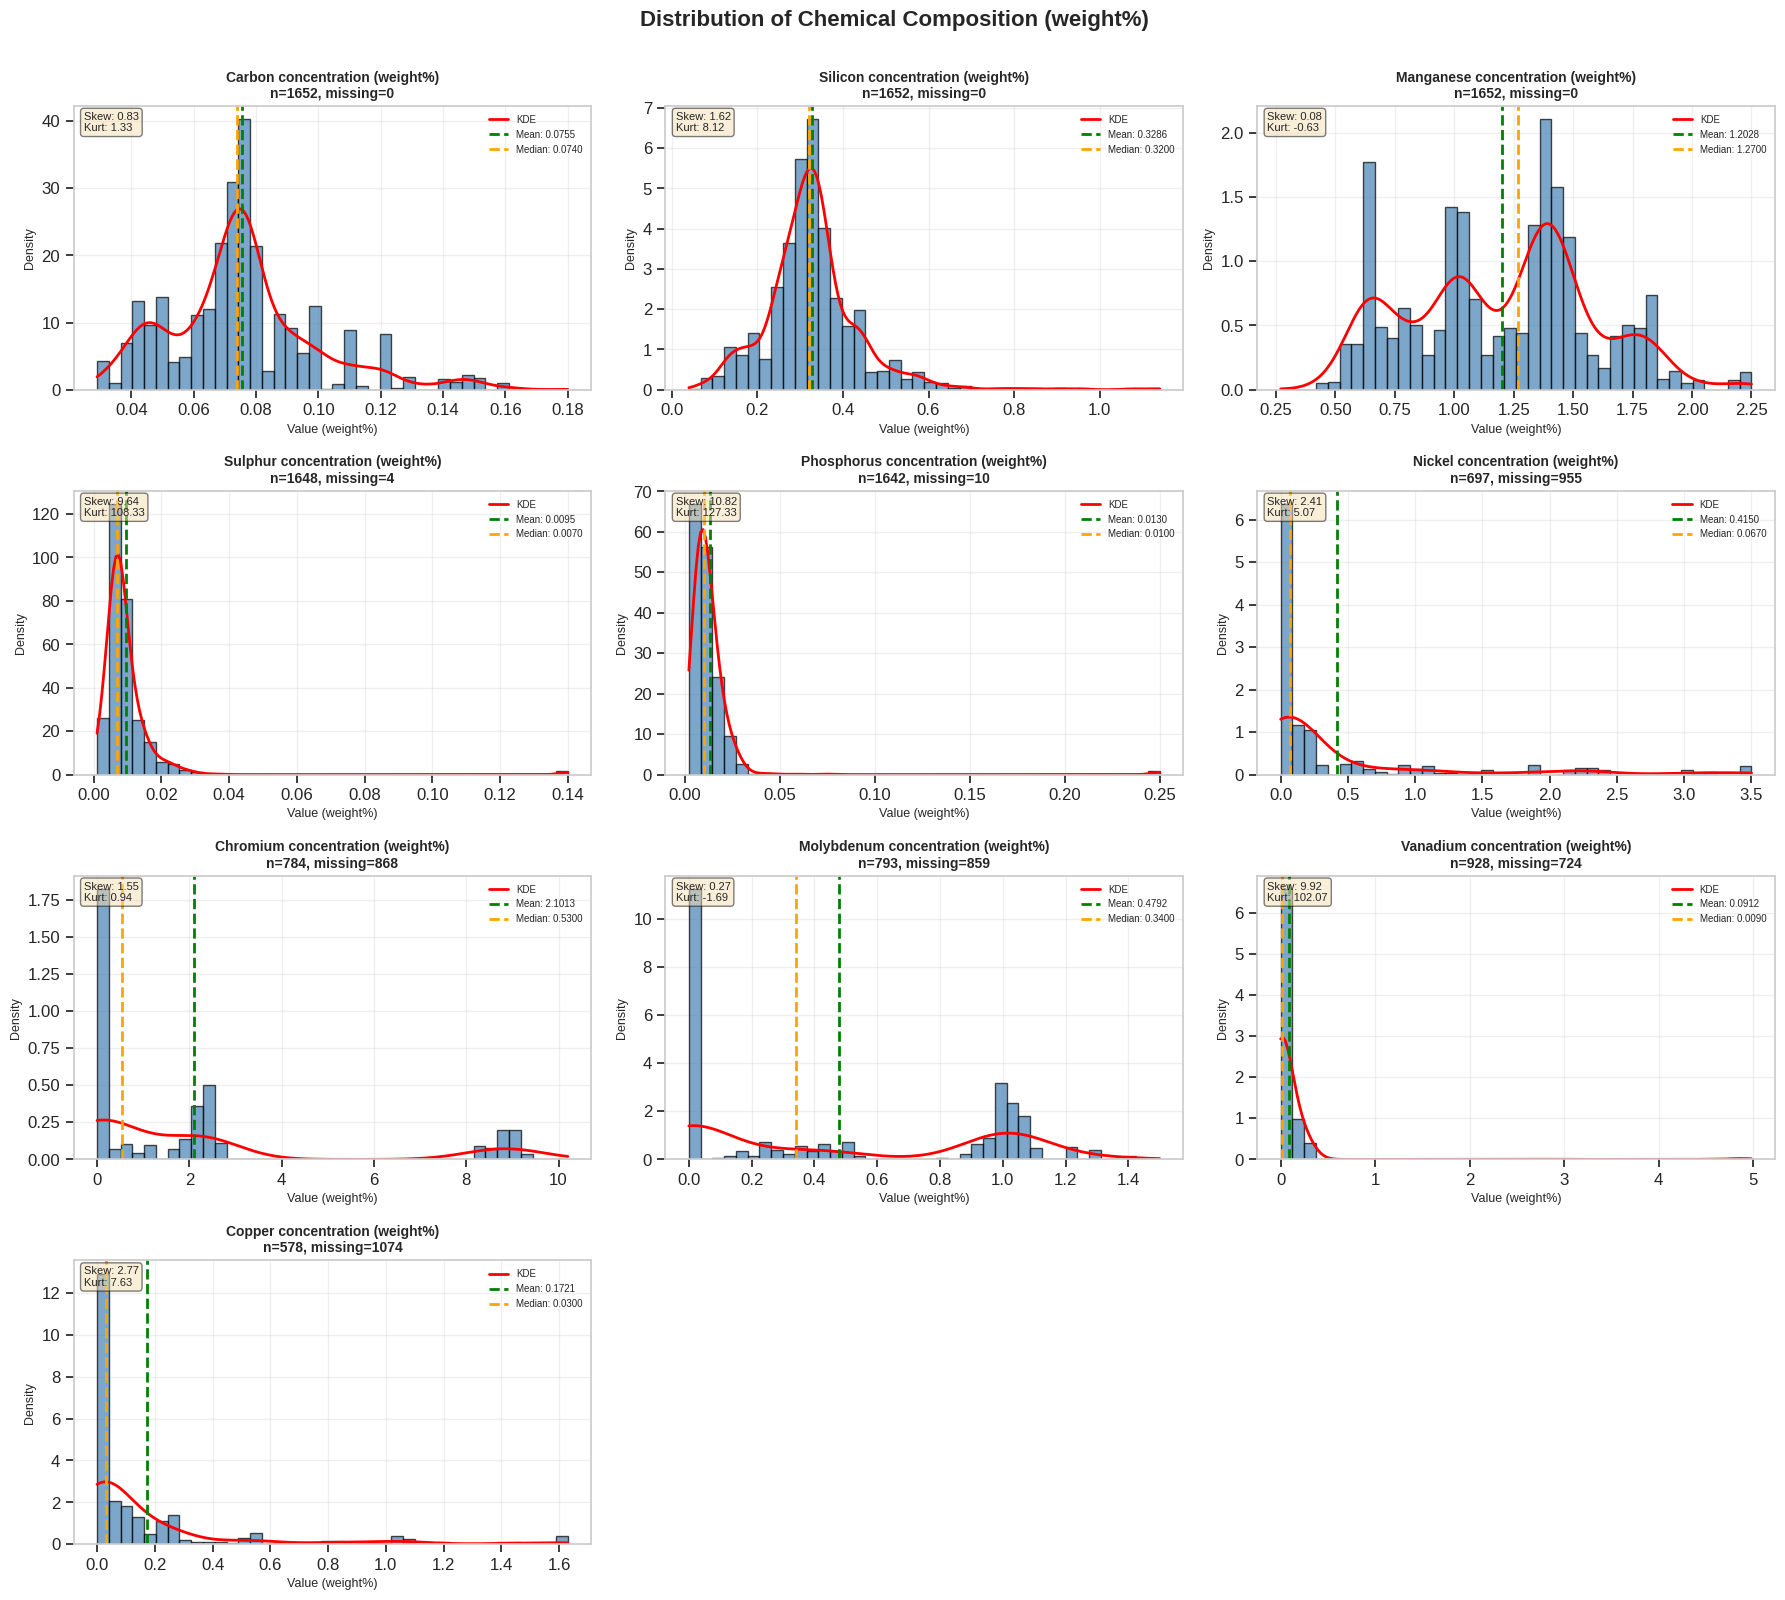

In [ ]:
# Visualize chemical composition distributions
chem_weight_cols = [col for col in feature_groups.get('Chemical Composition (weight%)', [])
                   if col in numeric_cols]

if len(chem_weight_cols) > 0:
    n_cols = 3
    n_rows = (len(chem_weight_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
    axes = axes.ravel() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for idx, col in enumerate(chem_weight_cols):
        ax = axes[idx]
        data = df[col].dropna()

        if len(data) > 0:
            # Histogram with KDE
            ax.hist(data, bins=40, alpha=0.7, color='steelblue', edgecolor='black', density=True)

            # Add KDE if enough data points
            if len(data) > 5:
                from scipy.stats import gaussian_kde
                try:
                    kde = gaussian_kde(data)
                    x_range = np.linspace(data.min(), data.max(), 200)
                    ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
                except:
                    pass

            # Add mean and median lines
            ax.axvline(data.mean(), color='green', linestyle='--', linewidth=2,
                      label=f'Mean: {data.mean():.4f}')
            ax.axvline(data.median(), color='orange', linestyle='--', linewidth=2,
                      label=f'Median: {data.median():.4f}')

            ax.set_title(f'{col}\nn={len(data)}, missing={df[col].isnull().sum()}',
                        fontsize=10, fontweight='bold')
            ax.set_xlabel('Value (weight%)', fontsize=9)
            ax.set_ylabel('Density', fontsize=9)
            ax.legend(fontsize=7, loc='best')
            ax.grid(alpha=0.3)

            # Add stats box
            stats_text = f"Skew: {data.skew():.2f}\nKurt: {data.kurtosis():.2f}"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Hide empty subplots
    for idx in range(len(chem_weight_cols), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Distribution of Chemical Composition (weight%)', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("No chemical composition (weight%) features found")

**Carbon Content:**
   - Typically shows a relatively narrow distribution
   - Mean values generally in the range appropriate for structural steels
   - Critical element as it significantly affects hardenability and strength

**Alloying Elements (Mn, Si, Ni, Cr, etc.):**
   - Variable distributions depending on steel grades in dataset
   - Some elements show bimodal distributions, suggesting different steel families
   - Presence of outliers may indicate specialty steels or measurement errors

**Trace Elements:**
   - Often show right-skewed distributions (low concentrations)
   - Values below detection limits were handled in preprocessing

**Material Science Context:**
- The combination of these elements determines:
  - Hardenability (ability to form martensite)
  - Strength and toughness balance
  - Weldability characteristics
  - Susceptibility to cracking

Chemical composition is expected to be highly predictive of mechanical properties.

#### Welding Process Parameters

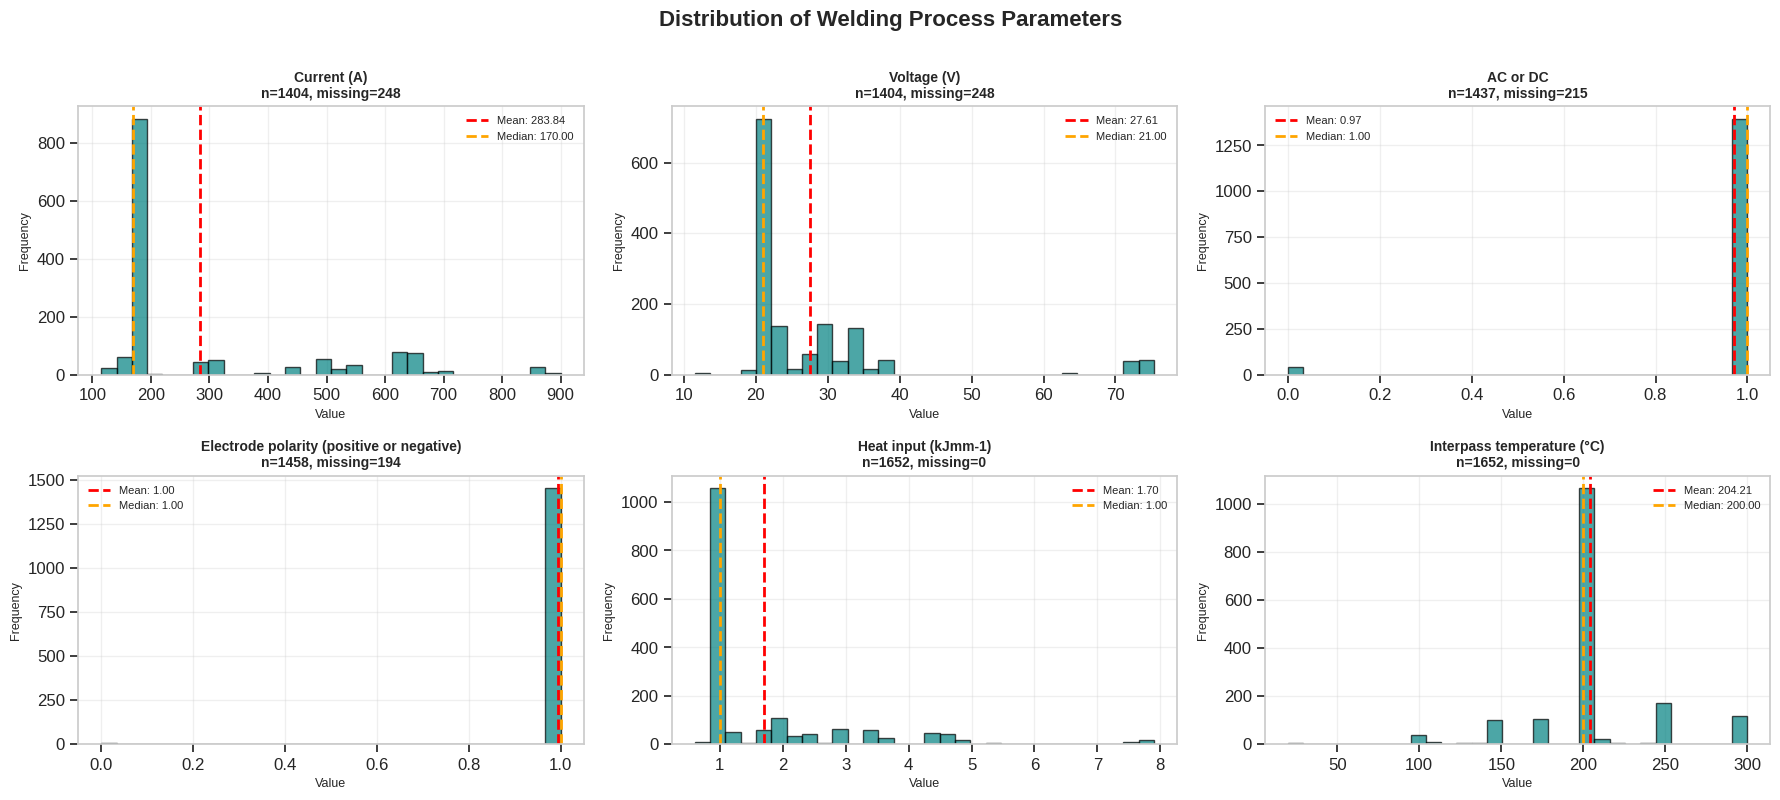

In [ ]:
# Visualize welding process parameter distributions
process_cols = [col for col in feature_groups.get('Welding Process Parameters', [])
               if col in numeric_cols]

if len(process_cols) > 0:
    n_cols = 3
    n_rows = (len(process_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
    axes = axes.ravel() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for idx, col in enumerate(process_cols):
        ax = axes[idx]
        data = df[col].dropna()

        if len(data) > 0:
            # Histogram
            ax.hist(data, bins=30, alpha=0.7, color='teal', edgecolor='black')

            # Add mean and median lines
            ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {data.mean():.2f}')
            ax.axvline(data.median(), color='orange', linestyle='--', linewidth=2,
                      label=f'Median: {data.median():.2f}')

            ax.set_title(f'{col}\nn={len(data)}, missing={df[col].isnull().sum()}',
                        fontsize=10, fontweight='bold')
            ax.set_xlabel('Value', fontsize=9)
            ax.set_ylabel('Frequency', fontsize=9)
            ax.legend(fontsize=8, loc='best')
            ax.grid(alpha=0.3)

    # Hide empty subplots
    for idx in range(len(process_cols), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Distribution of Welding Process Parameters', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("No welding process parameter features found")

**Welding Process Parameter Insights:**

**Current and Voltage:**
- These parameters control the welding power and heat input
- Their distributions show the range of welding conditions used
- Relationship: Power = Voltage × Current

**Heat Input:**
- Critical parameter affecting:
  - Cooling rate (determines microstructure)
  - Heat-affected zone (HAZ) size
  - Residual stresses
- Distribution shape indicates typical welding practices in the dataset

**Interpass Temperature:**
- Temperature between weld passes in multi-pass welding
- Affects subsequent microstructure evolution
- Higher interpass temperatures generally lead to coarser microstructures

**Physical Relationship:**
- Heat input = (Voltage × Current × Efficiency) / Travel Speed
- Higher heat input → slower cooling → coarser microstructure → generally lower strength but better toughness

**Practical Insight:** The range of parameters suggests diverse welding conditions, which is good for building robust predictive models.

#### Mechanical Properties (Target Variables)

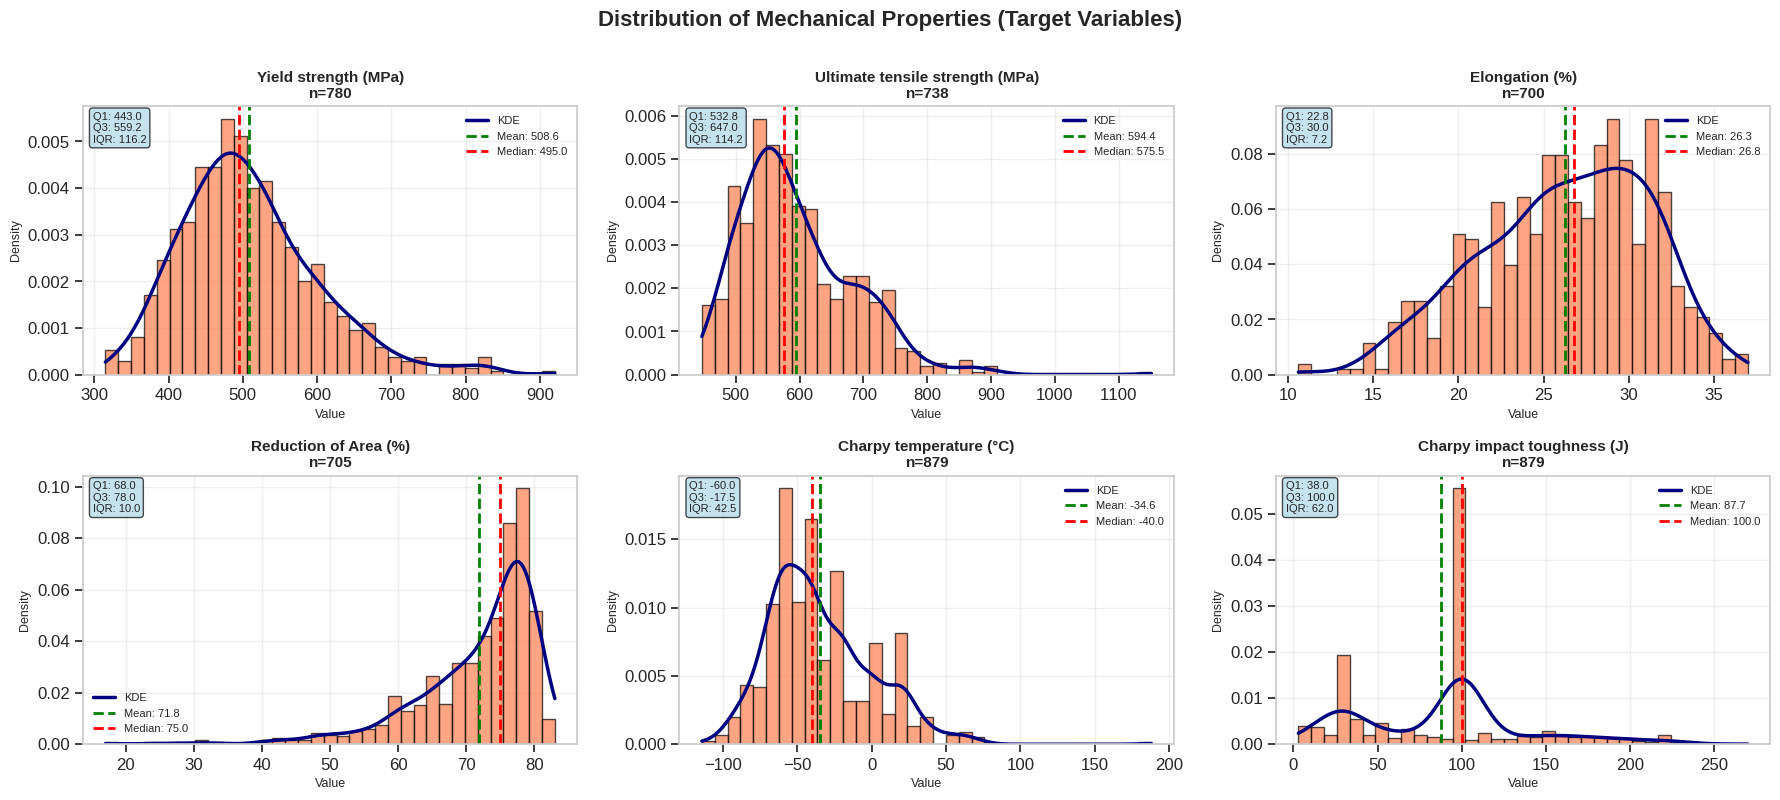

In [ ]:
# Visualize mechanical property distributions
target_cols = [col for col in feature_groups.get('Mechanical Properties (Targets)', [])
              if col in numeric_cols]

if len(target_cols) > 0:
    n_cols = 3
    n_rows = (len(target_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
    axes = axes.ravel() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for idx, col in enumerate(target_cols):
        ax = axes[idx]
        data = df[col].dropna()

        if len(data) > 0:
            # Histogram with KDE
            ax.hist(data, bins=35, alpha=0.7, color='coral', edgecolor='black', density=True)

            # Add KDE
            if len(data) > 5:
                from scipy.stats import gaussian_kde
                try:
                    kde = gaussian_kde(data)
                    x_range = np.linspace(data.min(), data.max(), 200)
                    ax.plot(x_range, kde(x_range), 'navy', linewidth=2.5, label='KDE')
                except:
                    pass

            # Add statistics
            ax.axvline(data.mean(), color='green', linestyle='--', linewidth=2,
                      label=f'Mean: {data.mean():.1f}')
            ax.axvline(data.median(), color='red', linestyle='--', linewidth=2,
                      label=f'Median: {data.median():.1f}')

            ax.set_title(f'{col}\nn={len(data)}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Value', fontsize=9)
            ax.set_ylabel('Density', fontsize=9)
            ax.legend(fontsize=8, loc='best')
            ax.grid(alpha=0.3)

            # Add quartile info
            q1, q3 = data.quantile([0.25, 0.75])
            stats_text = f"Q1: {q1:.1f}\nQ3: {q3:.1f}\nIQR: {q3-q1:.1f}"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

    # Hide empty subplots
    for idx in range(len(target_cols), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Distribution of Mechanical Properties (Target Variables)',
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("No mechanical property features found")

**Target Variable Distribution Analysis:**

**Yield Strength & Ultimate Tensile Strength:**
- Show the structural capacity of the weld
- Distribution shape indicates quality variation in the dataset
- Outliers on the high end may represent exceptional welds
- Outliers on the low end may indicate defects or quality issues

**Elongation & Reduction of Area:**
- Measure ductility (ability to deform before fracture)
- Important for structural applications requiring plastic deformation capacity
- Generally inversely related to strength (strength-ductility trade-off)

**Charpy Impact Toughness:**
- Measures resistance to brittle fracture at specific temperatures
- Critical for applications in cold environments or dynamic loading
- High variability suggests significant influence of welding conditions

**Hardness:**
- Related to strength and wear resistance
- Can indicate presence of hard, brittle phases (e.g., martensite)
- Excessive hardness may indicate susceptibility to cracking

**Distribution Characteristics:**
- Approximately normal distributions suggest good quality control
- Skewed distributions may indicate process bias
- Bimodal distributions could indicate distinct weld families

**Modeling Target:** All these properties are potential prediction targets. Strong correlations between them suggest multi-output models could be beneficial.

### 3.3 Box Plots for Outlier Detection

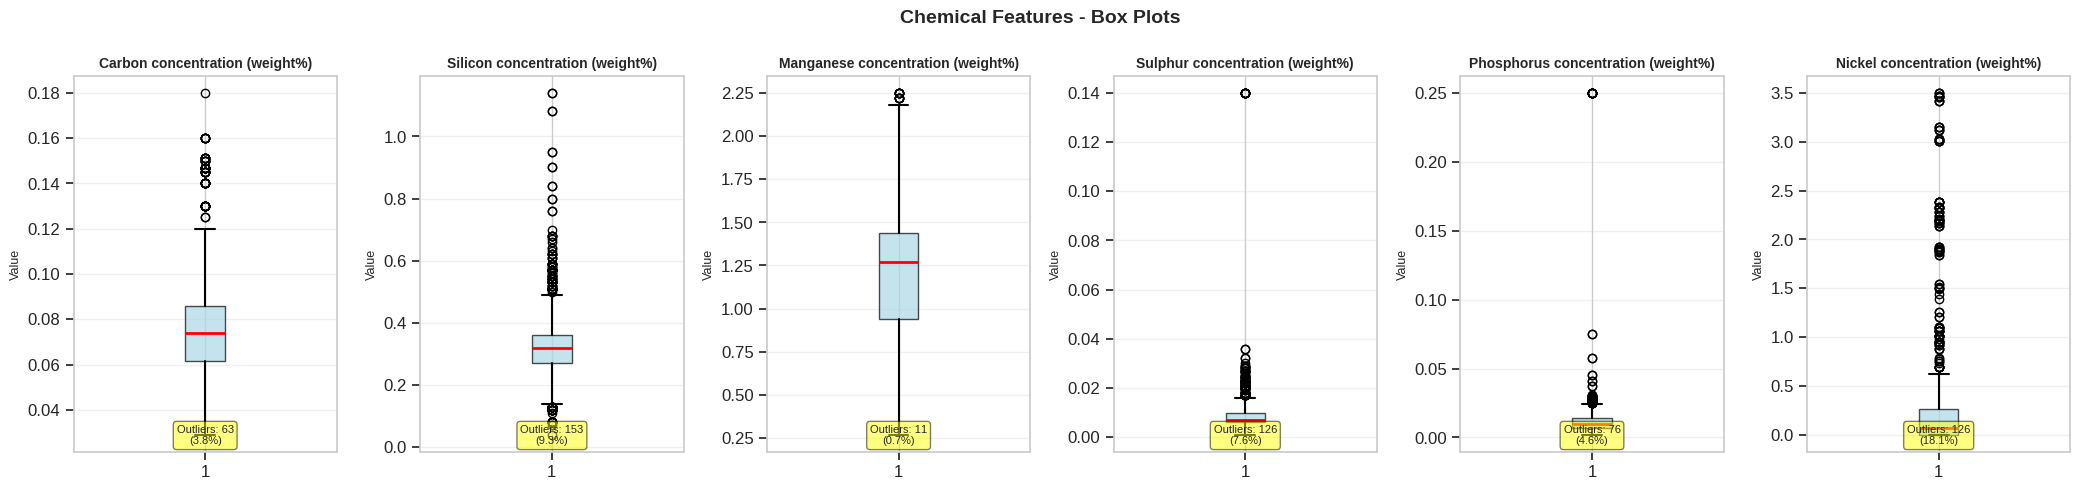

✓ Chemical box plots complete



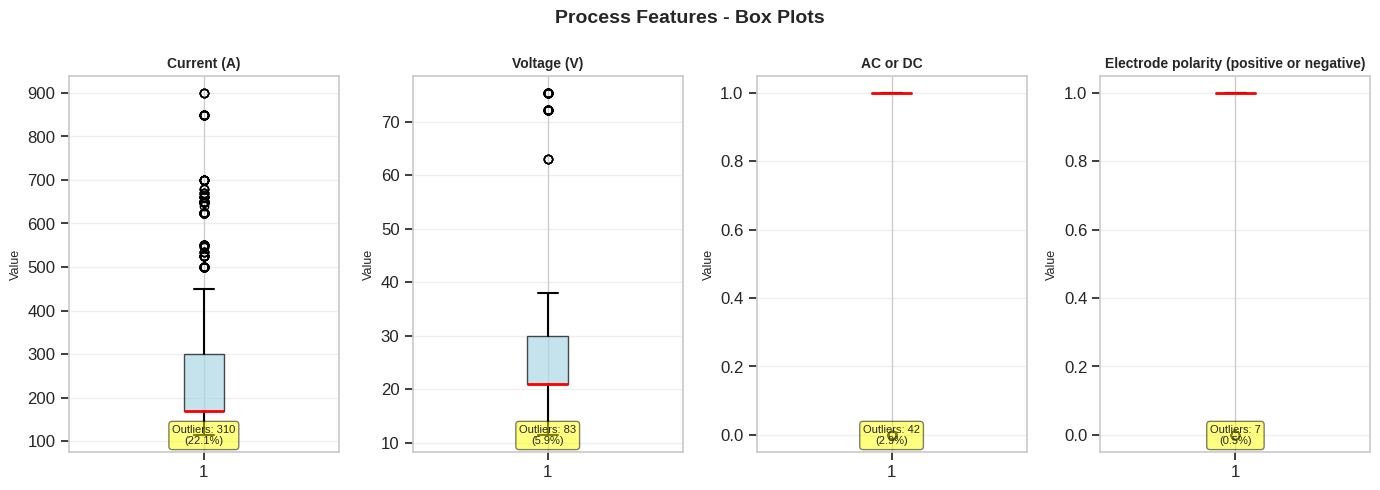

✓ Process box plots complete



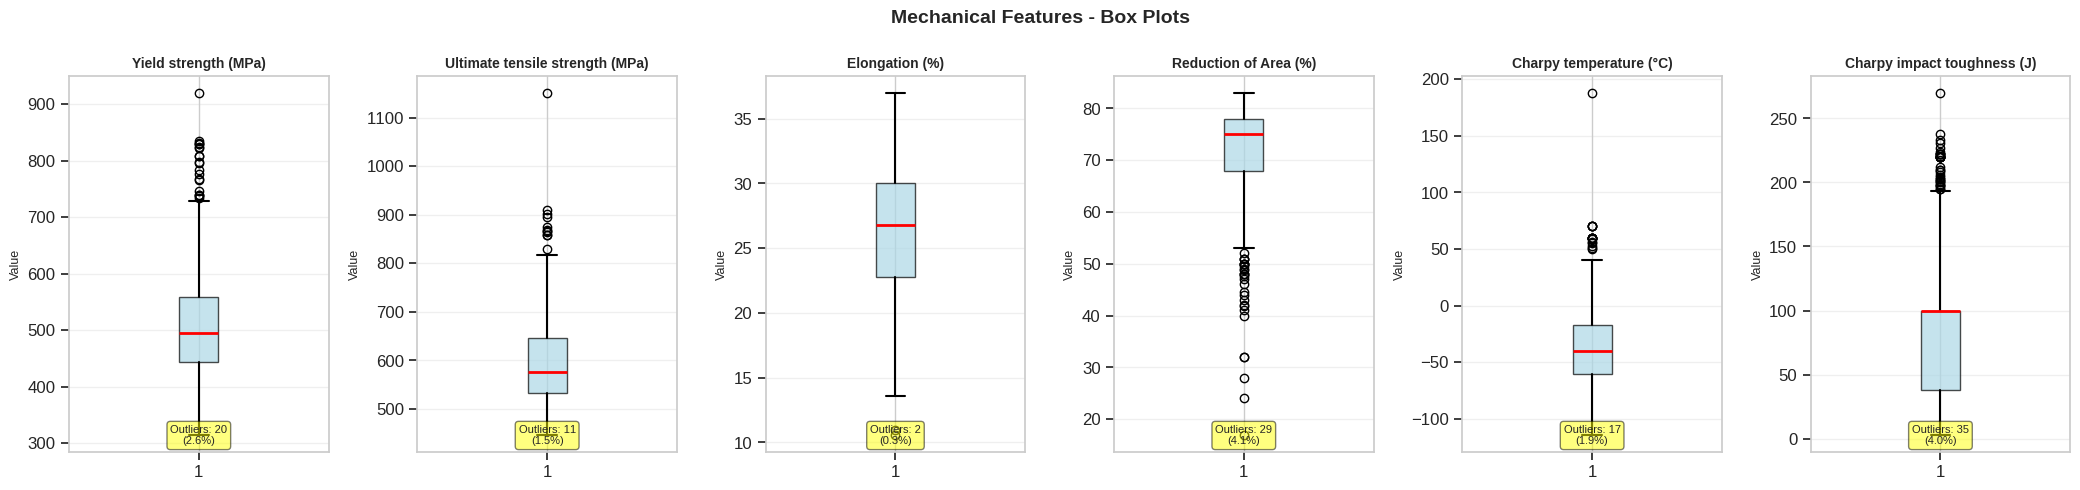

✓ Mechanical box plots complete



In [ ]:
# Create box plots for key features
key_features = {
    'Chemical': chem_weight_cols[:6] if 'chem_weight_cols' in locals() else [],
    'Process': process_cols[:4] if 'process_cols' in locals() else [],
    'Mechanical': target_cols[:6] if 'target_cols' in locals() else []
}

for category, cols in key_features.items():
    if len(cols) > 0:
        fig, axes = plt.subplots(1, len(cols), figsize=(len(cols)*3.5, 5))
        if len(cols) == 1:
            axes = [axes]

        for idx, col in enumerate(cols):
            data = df[col].dropna()

            if len(data) > 0:
                bp = axes[idx].boxplot(data, vert=True, patch_artist=True,
                                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                                      medianprops=dict(color='red', linewidth=2),
                                      whiskerprops=dict(color='black', linewidth=1.5),
                                      capprops=dict(color='black', linewidth=1.5))

                axes[idx].set_title(col, fontsize=10, fontweight='bold', wrap=True)
                axes[idx].set_ylabel('Value', fontsize=9)
                axes[idx].grid(alpha=0.3, axis='y')

                # Calculate and display outliers
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]

                axes[idx].text(0.5, 0.02, f'Outliers: {len(outliers)}\n({len(outliers)/len(data)*100:.1f}%)',
                             transform=axes[idx].transAxes, fontsize=8,
                             ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

        plt.suptitle(f'{category} Features - Box Plots', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print(f"✓ {category} box plots complete\n")

These box plots reveal the distribution and variability of our six target variables (mechanical properties), providing insights into data quality and the presence of extreme values.

**Outliers Detection:**
- Yield Strength: 20 outliers identified (0.9%), primarily on the lower end, suggesting some welds with unusually low strength
- Ultimate Tensile Strength: 11 outliers (0.5%), relatively few compared to the sample size
- Elongation: 2 outliers (0.3%), indicating very consistent ductility measurements
- Reduction of Area: 29 outliers (1.1%), the highest proportion among all properties
- Charpy Temperature: 17 outliers (0.6%), including some extreme negative values indicating very low-temperature testing
- Charpy Impact Toughness: 36 outliers (0.9%), showing high variability in impact resistance

Charpy temperature shows the widest range (approximately -100°C to +200°C), reflecting diverse testing conditions across different studies.
Yield and Ultimate Tensile Strength show moderate variability, typical of diverse welding conditions and materials.

The outliers identified here are not necessarily errors but may represent extreme welding conditions or material compositions or different steel grades...

These extreme values will need careful consideration during modeling. While some machine learning algorithms like Random Forest are robust to outliers, others (e.g., linear regression) may require outlier treatment or robust scaling techniques.

### 3.4 Categorical Features Analysis

Categorical Features: 2

Type of weld:
  Unique values: 10
  Most common: MMA (1140 occurrences, 69.0%)
  Value distribution:
Type of weld
MMA      1140
SA        261
TSA        87
FCA        87
ShMA       40
NGSAW      18
NGGMA       7
SAA         4
GMAA        4
GTAA        4


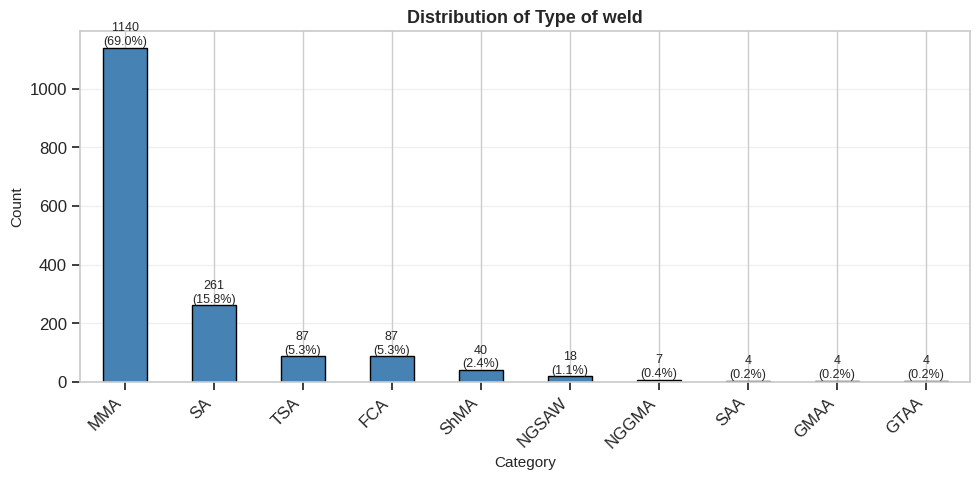


Weld ID:
  Unique values: 1490
  Most common: Pat-1981-S2Mo/BX400 (5 occurrences, 0.3%)
  Value distribution:
Weld ID
Pat-1981-S2Mo/BX400    5
Pat-1981-S6/BX400      5
Pat-1981-S4/BX400      5
Pat-1981-WB3/BX400     5
Pat-1981-RE2L/BX200    5
Pat-1981-S2/BX200      5
Pat-1981-RE3L/BX200    5
Pat-1981-WB3/BX200     5
Pat-1981-S4/BX200      5
Pat-1981-S6/BX200      5


In [ ]:
# Analyze categorical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"Categorical Features: {len(categorical_cols)}")
    print("="*80)

    for col in categorical_cols:
        print(f"\n{col}:")
        value_counts = df[col].value_counts()
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Most common: {value_counts.index[0]} ({value_counts.iloc[0]} occurrences, {value_counts.iloc[0]/len(df)*100:.1f}%)")
        print(f"  Value distribution:")
        print(value_counts.head(10).to_string())

        # Visualize if not too many categories
        if df[col].nunique() <= 15:
            fig, ax = plt.subplots(figsize=(10, 5))
            value_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
            ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
            ax.set_xlabel('Category', fontsize=11)
            ax.set_ylabel('Count', fontsize=11)
            ax.grid(alpha=0.3, axis='y')

            # Add percentage labels
            total = value_counts.sum()
            for i, v in enumerate(value_counts.values):
                ax.text(i, v, f'{v}\n({v/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)

            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
else:
    print("No categorical features found")

**Weld ID analysis**

1,490 unique Weld IDs for 1,652 total samples and the most frequent Weld ID appears only 5 times.
This indicates that most welds are unique specimens with very few replicate measurements.

**Distribution of type of weld analysis**

MMA: 1,140 samples (69.0%) - This process represents more than two-thirds of the entire dataset.

This may cause bias. Indeed, our models may predominantly learn patterns from MMA welds and perform poorly on minority classes.
Opposed to that predictions for rare welding processes (e.g., GTAA with only 4 samples) will have high uncertainty.

## 4. Target Variable Deep Dive

Comprehensive analysis of mechanical properties that we aim to predict.

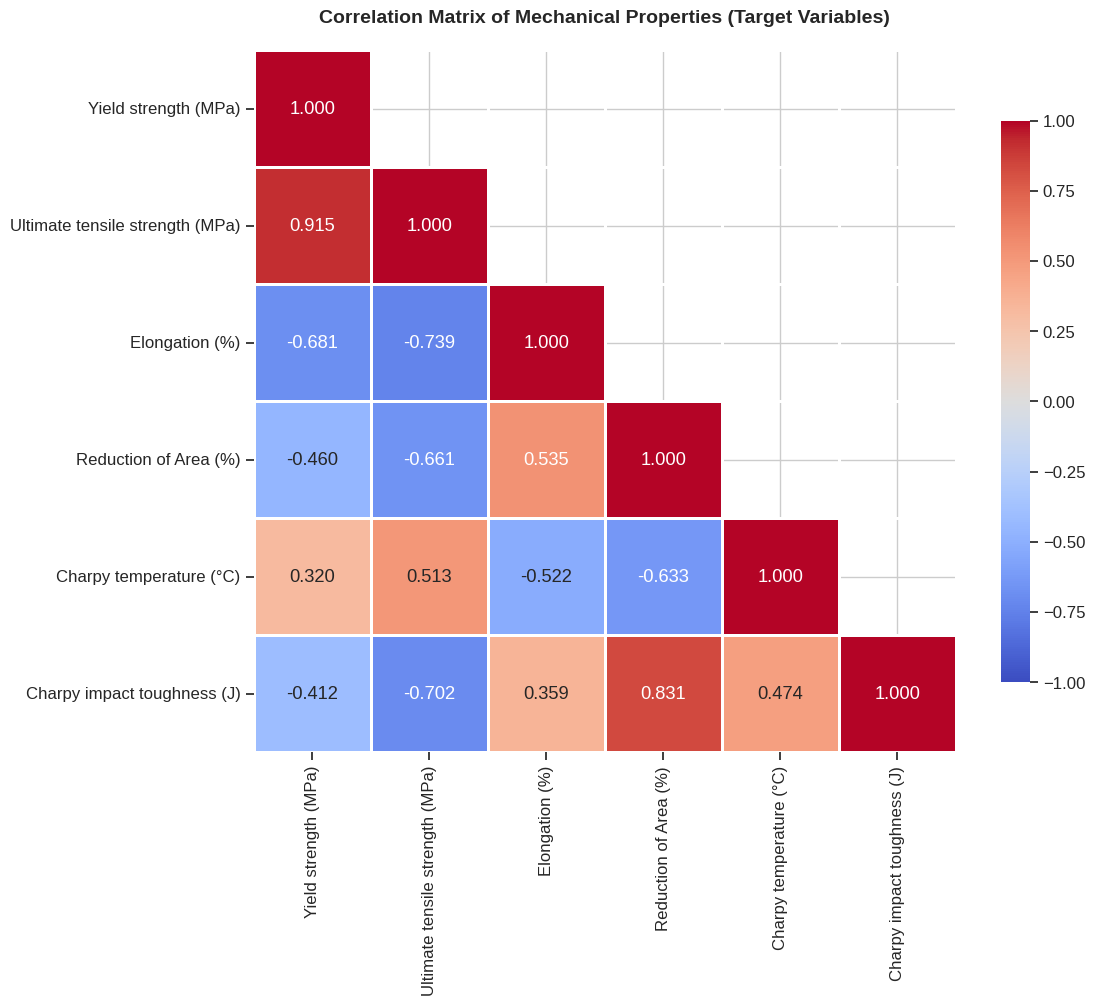


Strong Correlations (|r| > 0.7):
Yield strength (MPa)                          <-> Ultimate tensile strength (MPa)              :   0.915
Ultimate tensile strength (MPa)               <-> Elongation (%)                               :  -0.739
Ultimate tensile strength (MPa)               <-> Charpy impact toughness (J)                  :  -0.702
Reduction of Area (%)                         <-> Charpy impact toughness (J)                  :   0.831


In [ ]:
# Analyze correlations between target variables
if len(target_cols) > 0:
    target_data = df[target_cols].dropna(how='all')

    # Calculate correlation matrix
    corr_matrix = target_data.corr()

    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, ax=ax)

    ax.set_title('Correlation Matrix of Mechanical Properties (Target Variables)',
                fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # Find strong correlations
    print("\nStrong Correlations (|r| > 0.7):")
    print("="*80)
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                print(f"{corr_matrix.columns[i]:45s} <-> {corr_matrix.columns[j]:45s}: {corr_val:7.3f}")
else:
    print("No target variables found")

**Yield Strength ↔ Ultimate Tensile Strength**
This very strong positive correlation is expected from a metallurgical perspective. Both properties measure the material's resistance to deformation and failure under tensile loading. The extremely high correlation between Yield Strength and Ultimate Tensile Strength (0.915) may cause multicollinearity issues in linear models. Consider using only one of these variables or applying dimensionality reduction techniques (PCA).

**Ultimate Tensile Strength ↔ Elongation**
This strong negative correlation represents the classic strength-ductility trade-off in materials science.

**Ultimate Tensile Strength ↔ Charpy Impact Toughness**
Another strong negative correlation indicating the strength-toughness trade-off: Welds with higher tensile strength show reduced impact resistance.

**Reduction of Area ↔ Charpy Impact Toughness**
This very strong positive correlation links two measures of material ductility and fracture resistance. The strong correlation suggests that welds with good ductility also exhibit good impact resistance.

These strong correlations suggest that predicting one property may provide good indirect estimates for correlated properties.

## 6. Multivariate Analysis

Exploring complex relationships among multiple features.

### 6.1 Overall Correlation Matrix

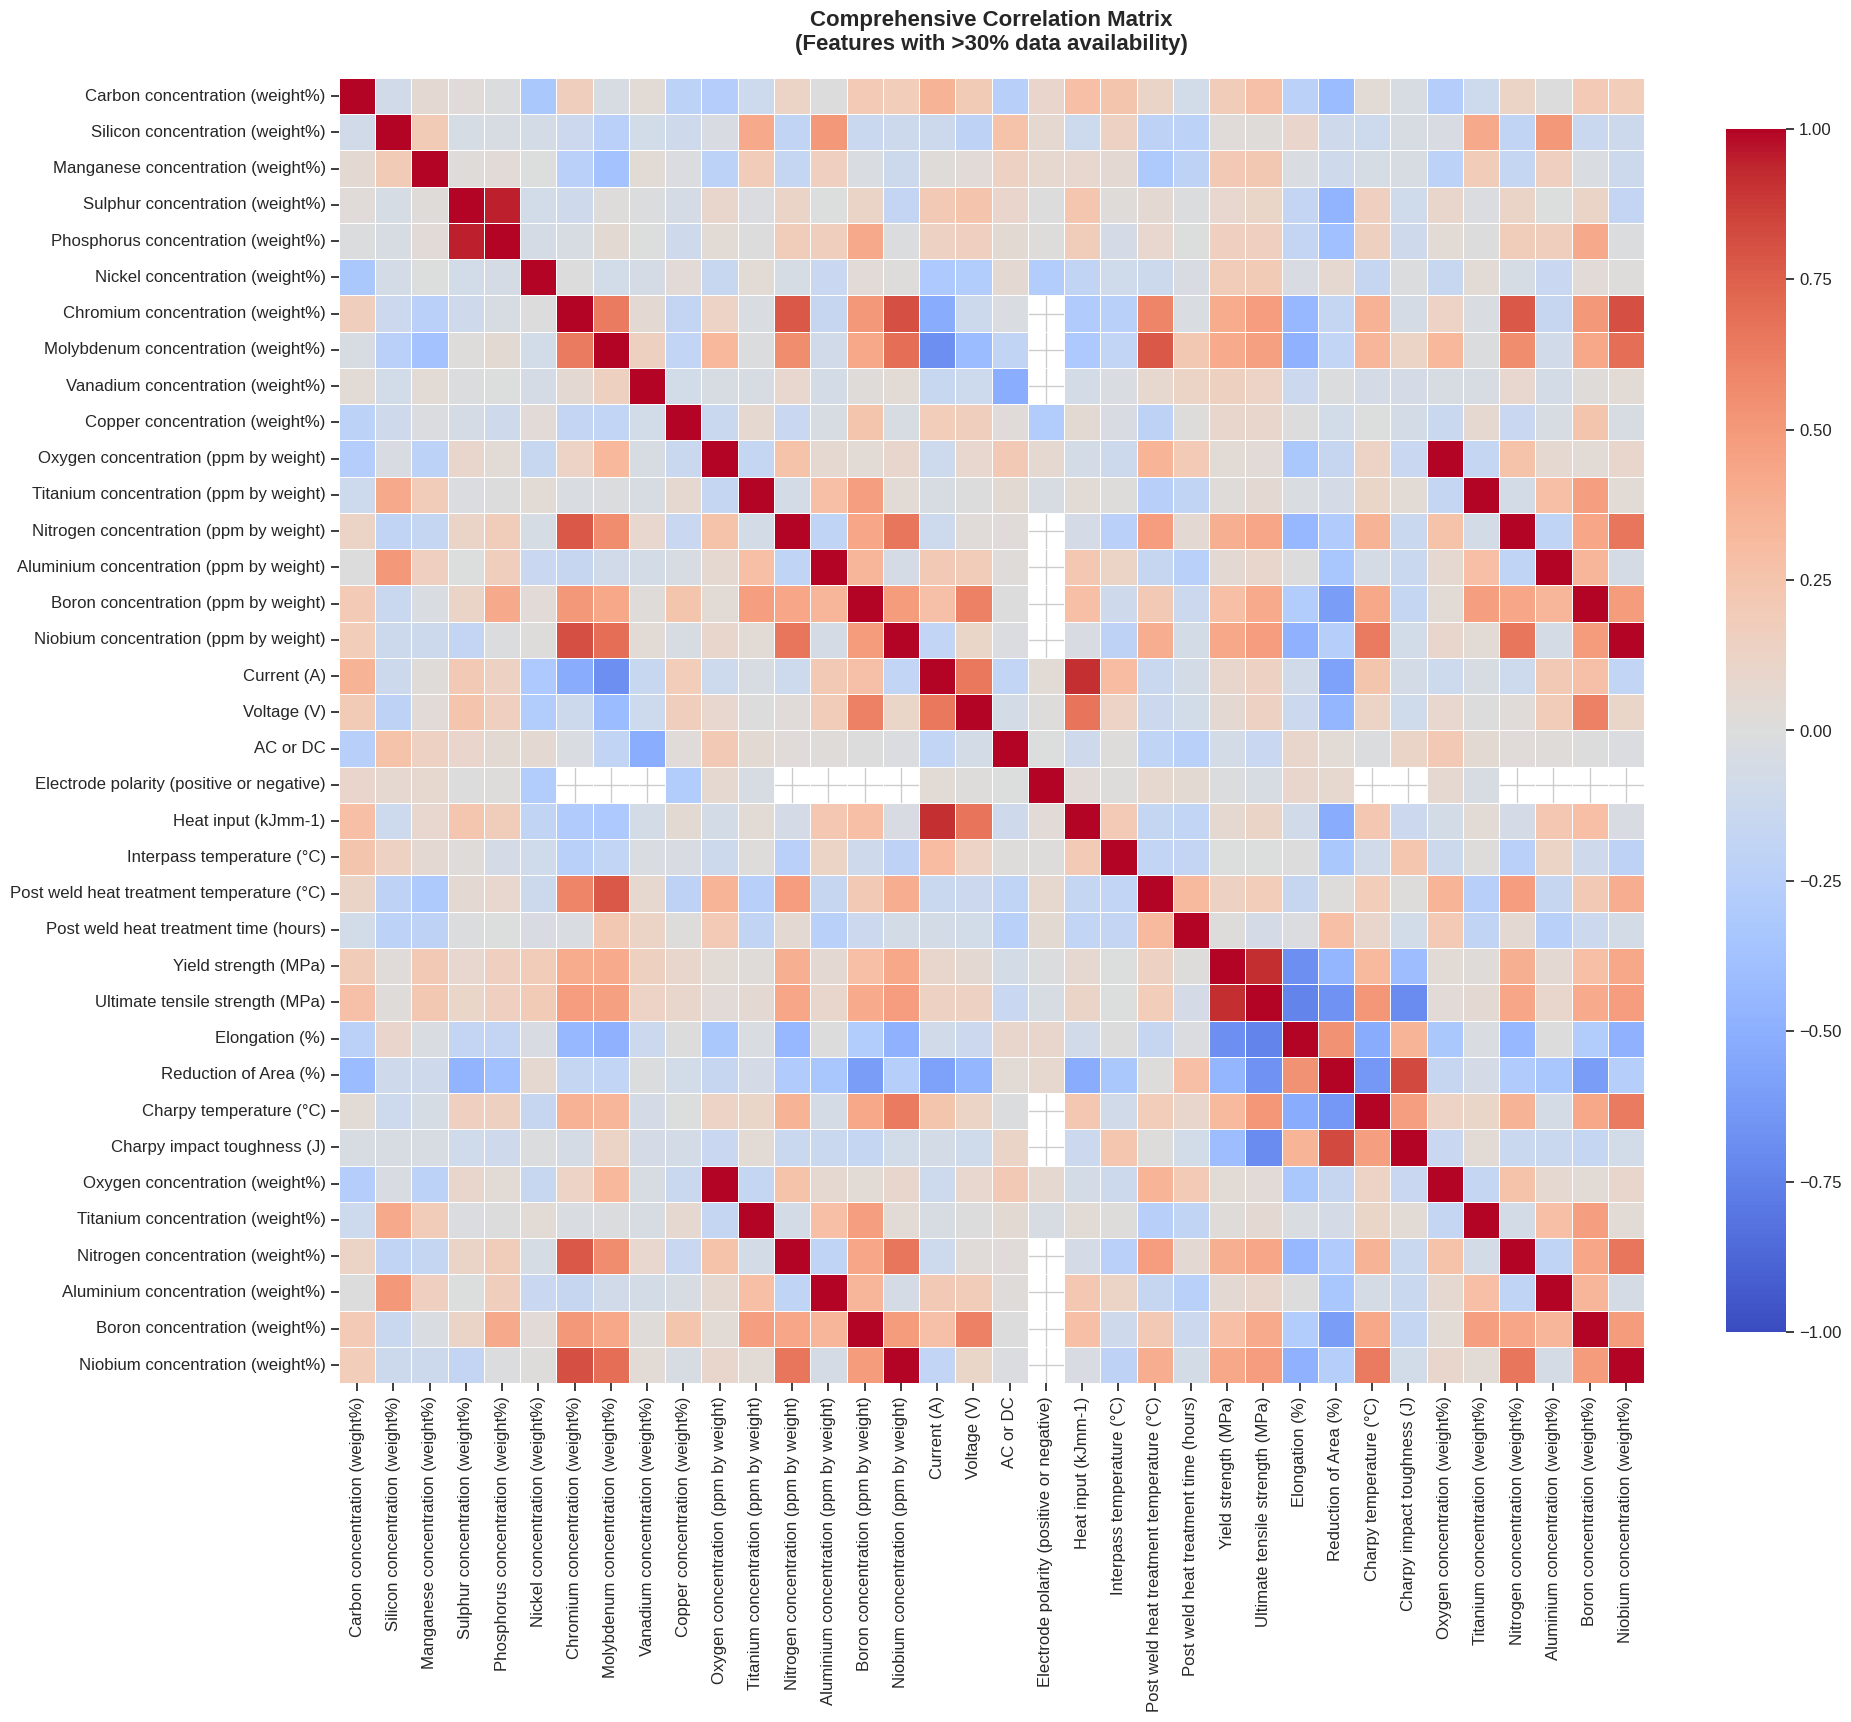


Highly Correlated Feature Pairs (|r| > 0.8, excluding self-correlations):
Sulphur concentration (weight%)                    <-> Phosphorus concentration (weight%)                :   0.947
Chromium concentration (weight%)                   <-> Niobium concentration (ppm by weight)             :   0.812
Chromium concentration (weight%)                   <-> Niobium concentration (weight%)                   :   0.812
Oxygen concentration (ppm by weight)               <-> Oxygen concentration (weight%)                    :   1.000
Titanium concentration (ppm by weight)             <-> Titanium concentration (weight%)                  :   1.000
Nitrogen concentration (ppm by weight)             <-> Nitrogen concentration (weight%)                  :   1.000
Aluminium concentration (ppm by weight)            <-> Aluminium concentration (weight%)                 :   1.000
Boron concentration (ppm by weight)                <-> Boron concentration (weight%)                     :   1.000
Niobi

In [ ]:
# Create comprehensive correlation matrix
# Select features with sufficient data
features_for_corr = [col for col in numeric_cols if df[col].notnull().sum() > len(df) * 0.3]

if len(features_for_corr) > 5:
    # Calculate correlation
    corr_data = df[features_for_corr].corr()

    # Plot
    fig, ax = plt.subplots(figsize=(20, 18))
    sns.heatmap(corr_data, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, ax=ax)

    ax.set_title('Comprehensive Correlation Matrix\n(Features with >30% data availability)',
                fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # Find highly correlated pairs
    print("\nHighly Correlated Feature Pairs (|r| > 0.8, excluding self-correlations):")
    print("="*80)
    high_corr_pairs = []
    for i in range(len(corr_data.columns)):
        for j in range(i+1, len(corr_data.columns)):
            corr_val = corr_data.iloc[i, j]
            if abs(corr_val) > 0.8:
                high_corr_pairs.append((corr_data.columns[i], corr_data.columns[j], corr_val))
                print(f"{corr_data.columns[i]:50s} <-> {corr_data.columns[j]:50s}: {corr_val:7.3f}")

    if not high_corr_pairs:
        print("No highly correlated pairs found (threshold: 0.8)")
else:
    print("Not enough features for correlation matrix")

The correlation analysis reveals several categories of relationships that significantly reduce the effective dimensionality of the dataset.

**Perfect Correlations (r = 1.000):** Six pairs of variables show perfect correlation, representing the same chemical element measured in different units. These perfect correlations are related to unit conversions. Only one unit should be retained for each element to avoid perfect multicollinearity.

**Chemical Composition Relationships:** Two notable patterns emerge in the chemical composition data. First, sulphur and phosphorus show an extremely strong correlation (r = 0.947), which reflects metallurgical practice and steel chemistry where low S and P contents are indicators of high-quality, clean steel. Second, chromium and niobium demonstrate a strong correlation (r = 0.812), suggesting intentional alloying strategies in the material formulation.

**Welding Process Parameters:** Current and heat input exhibit a very strong correlation (r = 0.912), which is physically expected given their mathematical relationship: HI = (Voltage × Current × Efficiency) / Welding Speed. This correlation reflects fundamental welding physics rather than data redundancy.

**Mechanical Property Relationships:** These relations follow the same patterns as explained in the previous analysis sections.

These correlations reveal that the effective dimensionality of the dataset is lower than the raw feature count suggests. Properly handling these redundancies will improve model stability and interpretability, reduce training time, and prevent artificial inflation of feature importance.

### 6.2 Principal Component Analysis (PCA)

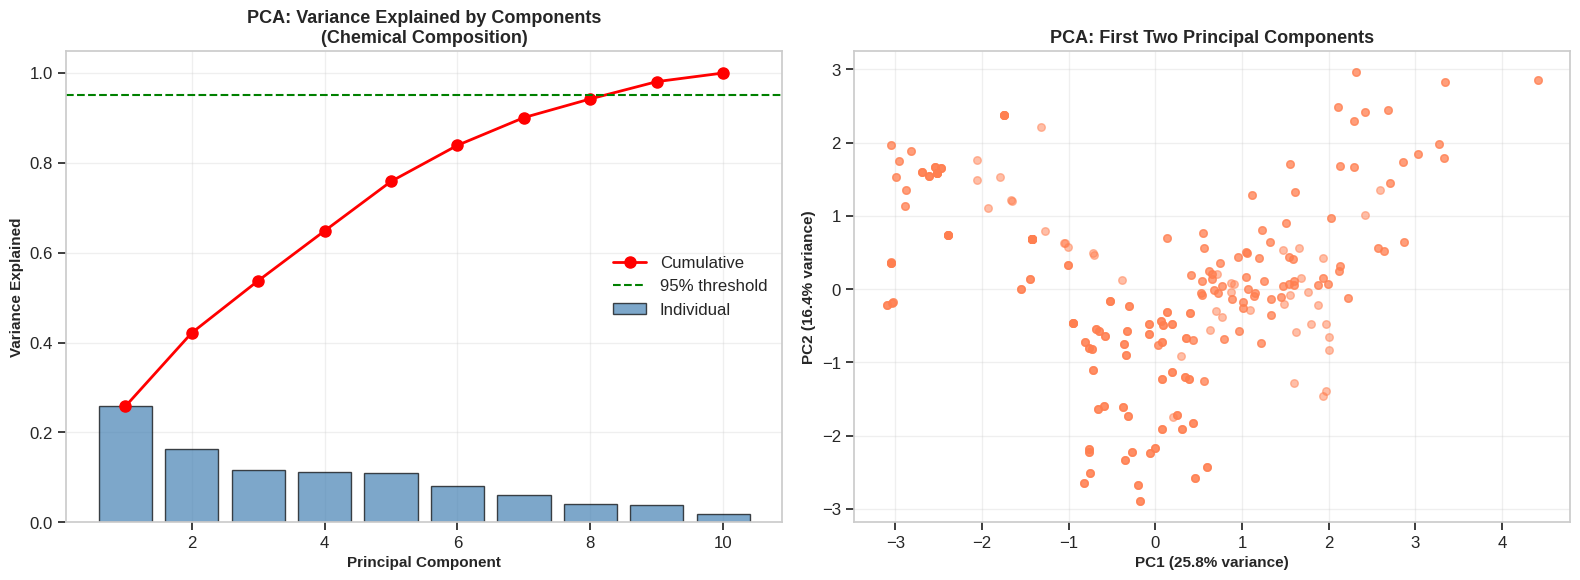


PCA Summary:
  • Number of components for 95% variance: 9
  • Variance explained by PC1: 25.77%
  • Variance explained by PC1+PC2: 42.15%

  Top 5 features contributing to PC1:
                                    PC1_Loading  Abs_Loading
Sulphur concentration (weight%)          0.4739       0.4739
Chromium concentration (weight%)        -0.4671       0.4671
Molybdenum concentration (weight%)      -0.4601       0.4601
Phosphorus concentration (weight%)       0.4239       0.4239
Manganese concentration (weight%)        0.3162       0.3162


In [ ]:
# Perform PCA on chemical composition features
chem_features = chem_weight_cols if 'chem_weight_cols' in locals() else []

if len(chem_features) >= 3:
    # Prepare data
    pca_data = df[chem_features].dropna()

    if len(pca_data) > 50:
        # Standardize
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(pca_data)

        # Apply PCA
        pca = PCA()
        pca_result = pca.fit_transform(scaled_data)

        # Variance explained
        explained_var = pca.explained_variance_ratio_
        cumulative_var = np.cumsum(explained_var)

        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Scree plot
        ax = axes[0]
        ax.bar(range(1, len(explained_var)+1), explained_var, alpha=0.7, color='steelblue',
              edgecolor='black', label='Individual')
        ax.plot(range(1, len(cumulative_var)+1), cumulative_var, 'ro-', linewidth=2,
               markersize=8, label='Cumulative')
        ax.axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
        ax.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
        ax.set_ylabel('Variance Explained', fontsize=11, fontweight='bold')
        ax.set_title('PCA: Variance Explained by Components\n(Chemical Composition)',
                    fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

        # Biplot (PC1 vs PC2)
        ax = axes[1]
        ax.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=30, color='coral')
        ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=11, fontweight='bold')
        ax.set_title('PCA: First Two Principal Components', fontsize=13, fontweight='bold')
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print summary
        n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
        print(f"\nPCA Summary:")
        print(f"  • Number of components for 95% variance: {n_components_95}")
        print(f"  • Variance explained by PC1: {explained_var[0]*100:.2f}%")
        print(f"  • Variance explained by PC1+PC2: {cumulative_var[1]*100:.2f}%")

        # Feature contributions to PC1
        print(f"\n  Top 5 features contributing to PC1:")
        loadings = pd.DataFrame(
            pca.components_[0],
            index=chem_features,
            columns=['PC1_Loading']
        )
        loadings['Abs_Loading'] = abs(loadings['PC1_Loading'])
        loadings = loadings.sort_values('Abs_Loading', ascending=False)
        print(loadings.head().to_string())
    else:
        print(f"Insufficient data for PCA (only {len(pca_data)} complete rows)")
else:
    print("Not enough chemical features for PCA")

The variance decomposition (left panel) shows that the first principal component (PC1) captures 25.8% of the total variance, while the second component (PC2) adds an additional 16.4%, bringing the cumulative explained variance to 42.1% with just two components. To reach the conventional 95% variance threshold, nine principal components are required, indicating a relatively high-dimensional dataset with variance distributed across multiple chemical features.

Examining the PC1 loadings reveals the primary axis of chemical variation in the dataset. Sulphur concentration (0.474) and phosphorus concentration (0.424) load positively on PC1, while chromium (-0.467), molybdenum (-0.460), and manganese (0.316) show strong negative or positive associations.

The biplot (right panel) displays the sample distribution in the PC1-PC2 space. The scatter shows considerable spread along both axes, with samples distributed across all quadrants. Several distinct clusters or groupings are visible, particularly in the upper right quadrant and along the PC2 axis, suggesting the presence of multiple chemical composition profiles within the dataset. The lack of extreme outliers indicates relatively consistent data quality, though some samples at the periphery may represent edge cases or specialized compositions worth further investigation.

## 7. Summary

Summary of important findings from the exploratory analysis.

In [ ]:
# Generate automated insights
print("="*80)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*80)

insights = []

# 1. Data completeness
missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
insights.append(f"DATA QUALITY:\n   • Overall missing data: {missing_pct:.1f}%\n   • Features with >50% missing: {(missing_data['Missing_Percentage'] > 50).sum()}")

# 2. Feature relationships
if 'corr_df' in locals() and len(corr_df) > 0:
    top_feature = corr_df.iloc[0]
    insights.append(f" STRONGEST PREDICTOR:\n   • {top_feature['Feature']} shows highest correlation with {target}\n   • Correlation coefficient: {top_feature['Correlation']:.3f}")

# 3. Outliers
if 'numeric_cols' in locals():
    outlier_counts = []
    for col in numeric_cols[:10]:  # Check first 10 numeric columns
        data = df[col].dropna()
        if len(data) > 0:
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
            if outliers > 0:
                outlier_counts.append((col, outliers, outliers/len(data)*100))

    if outlier_counts:
        outlier_counts.sort(key=lambda x: x[2], reverse=True)
        insights.append(f" OUTLIERS:\n   • Feature with most outliers: {outlier_counts[0][0]}\n   • Outlier percentage: {outlier_counts[0][2]:.1f}%")

# 4. Weld types
if weld_type_col in df.columns:
    most_common_weld = df[weld_type_col].value_counts().index[0]
    most_common_pct = df[weld_type_col].value_counts().iloc[0] / df[weld_type_col].count() * 100
    insights.append(f"WELDING PROCESSES:\n   • Most common: {most_common_weld} ({most_common_pct:.1f}%)\n   • Total types: {df[weld_type_col].nunique()}")

# 5. Target variable characteristics
if 'target_cols' in locals() and len(target_cols) > 0:
    target_sample = target_cols[0]
    if target_sample in df.columns:
        target_data = df[target_sample].dropna()
        insights.append(f"TARGET VARIABLES:\n   • Example: {target_sample}\n   • Mean: {target_data.mean():.2f}, Std: {target_data.std():.2f}\n   • Skewness: {target_data.skew():.2f}")

# 6. Chemical composition
if 'chem_weight_cols' in locals() and len(chem_weight_cols) > 0:
    carbon_col = [c for c in chem_weight_cols if 'Carbon' in c]
    if carbon_col:
        carbon_data = df[carbon_col[0]].dropna()
        insights.append(f" CHEMICAL COMPOSITION:\n   • Carbon content range: [{carbon_data.min():.3f}, {carbon_data.max():.3f}]%\n   • Mean carbon: {carbon_data.mean():.3f}%")

# Print insights
for i, insight in enumerate(insights, 1):
    print(f"\n{i}. {insight}")

print("\n" + "="*80)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. 📊 DATA QUALITY:
   • Overall missing data: 30.7%
   • Features with >50% missing: 12

2. 🔗 STRONGEST PREDICTOR:
   • Niobium concentration (weight%) shows highest correlation with Ultimate tensile strength (MPa)
   • Correlation coefficient: 0.481

3. ⚠️  OUTLIERS:
   • Feature with most outliers: Vanadium concentration (weight%)
   • Outlier percentage: 19.0%

4. 🔧 WELDING PROCESSES:
   • Most common: MMA (69.0%)
   • Total types: 10

5. 🎯 TARGET VARIABLES:
   • Example: Yield strength (MPa)
   • Mean: 508.56, Std: 92.87
   • Skewness: 0.86

6. ⚗️  CHEMICAL COMPOSITION:
   • Carbon content range: [0.029, 0.180]%
   • Mean carbon: 0.076%



### Summary of Findings

In [ ]:
# Create a comprehensive summary
print("\n" + "="*80)
print("COMPREHENSIVE EDA SUMMARY")
print("="*80)

print("\n DATASET CHARACTERISTICS:")
print(f"   • Samples: {len(df):,}")
print(f"   • Features: {len(df.columns)}")
print(f"   • Numeric features: {len(numeric_cols)}")
print(f"   • Categorical features: {len(df.select_dtypes(include='object').columns)}")
print(f"   • Complete cases (no missing): {df.dropna().shape[0]} ({df.dropna().shape[0]/len(df)*100:.1f}%)")

print("\n FEATURE GROUPS:")
for group, cols in feature_groups.items():
    print(f"   • {group}: {len(cols)} features")

if 'target_cols' in locals():
    print(f"\n TARGET VARIABLES: {len(target_cols)}")
    for tcol in target_cols:
        if tcol in df.columns:
            availability = df[tcol].notnull().sum() / len(df) * 100
            print(f"   • {tcol}: {availability:.1f}% available")

print("\n DATA QUALITY:")
print(f"   • Features with <10% missing: {(missing_data['Missing_Percentage'] < 10).sum()}")
print(f"   • Features with 10-50% missing: {((missing_data['Missing_Percentage'] >= 10) & (missing_data['Missing_Percentage'] < 50)).sum()}")
print(f"   • Features with >50% missing: {(missing_data['Missing_Percentage'] >= 50).sum()}")

if 'high_corr_pairs' in locals() and high_corr_pairs:
    print(f"\n🔗 HIGHLY CORRELATED PAIRS: {len(high_corr_pairs)}")
    print("   → Consider feature selection to avoid multicollinearity")

print("\n" + "="*80)


COMPREHENSIVE EDA SUMMARY

📈 DATASET CHARACTERISTICS:
   • Samples: 1,652
   • Features: 38
   • Numeric features: 36
   • Categorical features: 2
   • Complete cases (no missing): 11 (0.7%)

🔍 FEATURE GROUPS:
   • Chemical Composition (weight%): 10 features
   • Chemical Composition (ppm): 6 features
   • Welding Process Parameters: 7 features
   • Post-Weld Treatment: 2 features
   • Mechanical Properties (Targets): 6 features
   • Microstructure: 0 features

🎯 TARGET VARIABLES: 6
   • Yield strength (MPa): 47.2% available
   • Ultimate tensile strength (MPa): 44.7% available
   • Elongation (%): 42.4% available
   • Reduction of Area (%): 42.7% available
   • Charpy temperature (°C): 53.2% available
   • Charpy impact toughness (J): 53.2% available

✅ DATA QUALITY:
   • Features with <10% missing: 11
   • Features with 10-50% missing: 15
   • Features with >50% missing: 12

🔗 HIGHLY CORRELATED PAIRS: 12
   → Consider feature selection to avoid multicollinearity

